In [2]:
import pandas as pd

In [12]:
## LOAD THE DATA 
gm12878_sig=pd.read_csv("GM12878.tf.sig.tsv",header=None,sep='\t')
k562_sig=pd.read_csv("K562.tf.sig.tsv",header=None,sep='\t')
imr90_sig=pd.read_csv("IMR90.tf.sig.tsv",header=None,sep='\t')
h1esc_sig=pd.read_csv("H1ESC.tf.sig.tsv",header=None,sep='\t')
hepg2_sig=pd.read_csv("HEPG2.tf.sig.tsv",header=None,sep='\t')

In [13]:
gm12878_sig.head()

,0,1,2,3,4,5,6,7
0,chr7,145997367,145997384,-,RARA_MA0730.1,2.53,1.89,0.0
1,chr7,145997367,145997384,-,Rara.mouse_nuclearreceptor_2,2.53,1.89,0.0
2,chr7,145997367,145997384,-,RARA_nuclearreceptor_3,2.53,1.89,0.0
3,chr7,145997367,145997384,-,RARA_nuclearreceptor_6,2.53,1.89,0.0
4,chr7,145997367,145997384,-,Rarb_MA0858.1,2.53,1.89,0.0


In [5]:
gm12878_all=pd.read_csv("../gm12878_dnase/tf_scan/GM12878.idr.peaks.50bp.around.summit.overlap.tf.all.bed",sep='\t',header=None)



In [14]:
gm12878_all.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,chr1,629097,629113,SIX2_MA1119.1,8.536966,-,GTCTCAGGCTTCAACA,chr1,629103,629203,629153,10
1,chr1,629118,629133,AP2A_HUMAN.H11MO.0.A,7.563299,-,TACGCCGCAGGCCCC,chr1,629103,629203,629153,15
2,chr1,629118,629140,SP1_HUMAN.H11MO.0.A,6.461498,-,TACGCCGCAGGCCCCTTCGCCC,chr1,629103,629203,629153,22
3,chr1,629119,629133,AP2C_HUMAN.H11MO.0.A,8.327926,-,ACGCCGCAGGCCCC,chr1,629103,629203,629153,14
4,chr1,629120,629130,AP2B_HUMAN.H11MO.0.B,8.781151,-,CGCCGCAGGC,chr1,629103,629203,629153,10


In [6]:
k562_all=pd.read_csv("../k562_dnase/bpnet/tf_scan/K562.idr.peaks.50bp.around.summit.overlap.tf.all.bed",sep='\t',header=None)


In [7]:
imr90_all=pd.read_csv("../imr90_dnase/tf_scan/IMR90.idr.peaks.50bp.around.summit.overlap.tf.all.bed",sep='\t',header=None)


In [8]:
h1esc_all=pd.read_csv("../h1esc_dnase/tf_scan/H1ESC.idr.peaks.50bp.around.summit.overlap.tf.all.bed",sep='\t',header=None)


In [9]:
hepg2_all=pd.read_csv("../hepg2_dnase/tf_scan/HEPG2.idr.peaks.50bp.around.summit.overlap.tf.all.bed",sep='\t',header=None)


In [10]:
gm12878_peaks=99749
k562_peaks=154628
imr90_peaks=164194
h1esc_peaks=70662
hepg2_peaks=135628



In [45]:
def aggregate_df(df_sig,df_all,peaks,cell):
    df_sig_n=pd.DataFrame(df_sig.groupby(4).count()[0])
    df_all_n=pd.DataFrame(df_all.groupby(3).count()[0])
    df_sig_sum=df_sig.groupby(4).sum()[[5,6,7]]
    merged=df_sig_n.merge(df_all_n,how='outer',left_index=True,right_index=True)
    merged=merged.merge(df_sig_sum,how='outer',left_index=True,right_index=True)
    merged=merged.rename({'0_x':cell+'.N.sig',
                         '0_y':cell+'.N',
                         5:cell+'.Sum.PvalMean',
                         6:cell+'.Sum.GeomMeanPval',
                         7:cell+'.Sum.Pval90Percentile'},axis='columns')
    #get normalized vals 
    merged[cell+".N.sig/Peaks"]=merged[cell+".N.sig"]/peaks
    merged[cell+".N.sig/N"]=merged[cell+".N.sig"]/merged[cell+".N"]
    merged[cell+'.Sum.PvalMean/Peaks']=merged[cell+".Sum.PvalMean"]/peaks
    merged[cell+'.Sum.GeomMeanPval/Peaks']=merged[cell+".Sum.GeomMeanPval"]/peaks
    merged[cell+'.Sum.Pval90Percentile/Peaks']=merged[cell+".Sum.Pval90Percentile"]/peaks
    return merged 


In [48]:
merged_gm12878=aggregate_df(gm12878_sig,gm12878_all,gm12878_peaks,'GM12878')
merged_k562=aggregate_df(k562_sig,k562_all,k562_peaks,'K562')
merged_imr90=aggregate_df(imr90_sig,imr90_all,imr90_peaks,'IMR90')
merged_h1esc=aggregate_df(h1esc_sig,h1esc_all,h1esc_peaks,'H1ESC')
merged_hepg2=aggregate_df(hepg2_sig,hepg2_all,hepg2_peaks,'HEPG2')


In [49]:
merged=merged_gm12878.merge(merged_k562,how='outer',left_index=True,right_index=True)
merged=merged.merge(merged_imr90,how='outer',left_index=True,right_index=True)
merged=merged.merge(merged_h1esc,how='outer',left_index=True,right_index=True)
merged=merged.merge(merged_hepg2,how='outer',left_index=True,right_index=True)

In [50]:
merged

,GM12878.N.sig,GM12878.N,GM12878.Sum.PvalMean,GM12878.Sum.GeomMeanPval,GM12878.Sum.Pval90Percentile,GM12878.N.sig/Peaks,GM12878.N.sig/N,GM12878.Sum.PvalMean/Peaks,GM12878.Sum.GeomMeanPval/Peaks,GM12878.Sum.Pval90Percentile/Peaks,...,HEPG2.N.sig,HEPG2.N,HEPG2.Sum.PvalMean,HEPG2.Sum.GeomMeanPval,HEPG2.Sum.Pval90Percentile,HEPG2.N.sig/Peaks,HEPG2.N.sig/N,HEPG2.Sum.PvalMean/Peaks,HEPG2.Sum.GeomMeanPval/Peaks,HEPG2.Sum.Pval90Percentile/Peaks
4,,,,,,,,,,,,,,,,,,,,,
AHR_HUMAN.H11MO.0.B,974,2905,3416.89,6514.08,856.19,0.009765,0.335284,0.034255,0.065305,0.008583,...,918.0,2876.0,2924.31,7283.24,845.39,0.006769,0.319193,0.021561,0.053700,0.006233
AIRE_HUMAN.H11MO.0.C,450,1648,1397.70,13095.40,98.25,0.004511,0.273058,0.014012,0.131284,0.000985,...,671.0,2102.0,2040.19,14220.61,185.48,0.004947,0.319220,0.015043,0.104850,0.001368
ALX1_HUMAN.H11MO.0.B,69,443,195.79,138.88,8.25,0.000692,0.155756,0.001963,0.001392,0.000083,...,177.0,575.0,509.80,379.99,53.61,0.001305,0.307826,0.003759,0.002802,0.000395
ALX3_MA0634.1,160,746,449.04,354.03,49.51,0.001604,0.214477,0.004502,0.003549,0.000496,...,154.0,745.0,445.77,349.45,66.12,0.001135,0.206711,0.003287,0.002577,0.000488
ALX3_homeodomain_1,193,799,549.64,436.05,66.79,0.001935,0.241552,0.005510,0.004371,0.000670,...,202.0,799.0,600.83,791.32,86.94,0.001489,0.252816,0.004430,0.005834,0.000641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zfp740.mouse_C2H2_1,13644,36699,243359.92,564045.06,47428.51,0.136783,0.371781,2.439723,5.654644,0.475479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zfx_MA0146.2,4115,32589,12321.17,31583.07,1765.22,0.041254,0.126270,0.123522,0.316625,0.017697,...,8597.0,40218.0,25036.33,41595.56,5400.54,0.063387,0.213760,0.184596,0.306689,0.039819
Zic3.mouse_C2H2_1,4775,21570,113428.48,429383.57,4392.96,0.047870,0.221372,1.137139,4.304640,0.044040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
merged.to_csv('TF.scan.summary.canonical.dnase.txt',index=True,header=True,sep='\t')

In [52]:
merged.columns


Index(['GM12878.N.sig', 'GM12878.N', 'GM12878.Sum.PvalMean',
       'GM12878.Sum.GeomMeanPval', 'GM12878.Sum.Pval90Percentile',
       'GM12878.N.sig/Peaks', 'GM12878.N.sig/N', 'GM12878.Sum.PvalMean/Peaks',
       'GM12878.Sum.GeomMeanPval/Peaks', 'GM12878.Sum.Pval90Percentile/Peaks',
       'K562.N.sig', 'K562.N', 'K562.Sum.PvalMean', 'K562.Sum.GeomMeanPval',
       'K562.Sum.Pval90Percentile', 'K562.N.sig/Peaks', 'K562.N.sig/N',
       'K562.Sum.PvalMean/Peaks', 'K562.Sum.GeomMeanPval/Peaks',
       'K562.Sum.Pval90Percentile/Peaks', 'IMR90.N.sig', 'IMR90.N',
       'IMR90.Sum.PvalMean', 'IMR90.Sum.GeomMeanPval',
       'IMR90.Sum.Pval90Percentile', 'IMR90.N.sig/Peaks', 'IMR90.N.sig/N',
       'IMR90.Sum.PvalMean/Peaks', 'IMR90.Sum.GeomMeanPval/Peaks',
       'IMR90.Sum.Pval90Percentile/Peaks', 'H1ESC.N.sig', 'H1ESC.N',
       'H1ESC.Sum.PvalMean', 'H1ESC.Sum.GeomMeanPval',
       'H1ESC.Sum.Pval90Percentile', 'H1ESC.N.sig/Peaks', 'H1ESC.N.sig/N',
       'H1ESC.Sum.PvalMean/Peaks', '

In [77]:
merged=pd.read_csv("TF.scan.summary.canonical.dnase.txt",header=0,index_col=['4'],sep='\t')
merged

,GM12878.N.sig,GM12878.N,GM12878.Sum.PvalMean,GM12878.Sum.GeomMeanPval,GM12878.Sum.Pval90Percentile,GM12878.N.sig/Peaks,GM12878.N.sig/N,GM12878.Sum.PvalMean/Peaks,GM12878.Sum.GeomMeanPval/Peaks,GM12878.Sum.Pval90Percentile/Peaks,...,HEPG2.N.sig,HEPG2.N,HEPG2.Sum.PvalMean,HEPG2.Sum.GeomMeanPval,HEPG2.Sum.Pval90Percentile,HEPG2.N.sig/Peaks,HEPG2.N.sig/N,HEPG2.Sum.PvalMean/Peaks,HEPG2.Sum.GeomMeanPval/Peaks,HEPG2.Sum.Pval90Percentile/Peaks
4,,,,,,,,,,,,,,,,,,,,,
AHR_HUMAN.H11MO.0.B,974,2905,3416.89,6514.08,856.19,0.009765,0.335284,0.034255,0.065305,0.008583,...,918.0,2876.0,2924.31,7283.24,845.39,0.006769,0.319193,0.021561,0.053700,0.006233
AIRE_HUMAN.H11MO.0.C,450,1648,1397.70,13095.40,98.25,0.004511,0.273058,0.014012,0.131284,0.000985,...,671.0,2102.0,2040.19,14220.61,185.48,0.004947,0.319220,0.015043,0.104850,0.001368
ALX1_HUMAN.H11MO.0.B,69,443,195.79,138.88,8.25,0.000692,0.155756,0.001963,0.001392,0.000083,...,177.0,575.0,509.80,379.99,53.61,0.001305,0.307826,0.003759,0.002802,0.000395
ALX3_MA0634.1,160,746,449.04,354.03,49.51,0.001604,0.214477,0.004502,0.003549,0.000496,...,154.0,745.0,445.77,349.45,66.12,0.001135,0.206711,0.003287,0.002577,0.000488
ALX3_homeodomain_1,193,799,549.64,436.05,66.79,0.001935,0.241552,0.005510,0.004371,0.000670,...,202.0,799.0,600.83,791.32,86.94,0.001489,0.252816,0.004430,0.005834,0.000641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN4_C2H2_1,991,5673,2884.41,12751.78,356.60,0.009935,0.174687,0.028917,0.127839,0.003575,...,1879.0,6217.0,5512.92,16493.18,888.14,0.013854,0.302236,0.040647,0.121606,0.006548
ZSCAN4_MA1155.1,991,5673,2884.41,12751.78,356.60,0.009935,0.174687,0.028917,0.127839,0.003575,...,1879.0,6217.0,5512.92,16493.18,888.14,0.013854,0.302236,0.040647,0.121606,0.006548
Zfx_MA0146.2,4115,32589,12321.17,31583.07,1765.22,0.041254,0.126270,0.123522,0.316625,0.017697,...,8597.0,40218.0,25036.33,41595.56,5400.54,0.063387,0.213760,0.184596,0.306689,0.039819


In [91]:
import seaborn as sns; 


In [92]:
sns.set_color_codes()

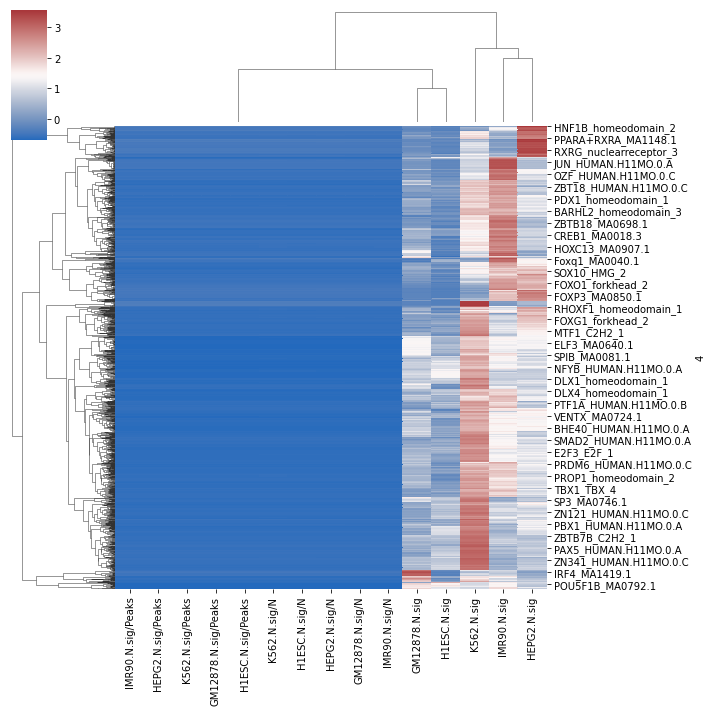

In [106]:
filtered=merged.filter(regex='.N.sig')
filtered.head()
sns.clustermap(filtered,
               z_score=0,
              cmap='vlag',
              figsize=(10,10))